<a href="https://colab.research.google.com/github/meri-crush/Experiment_Learning_AI/blob/main/My_First_Simple_WorkFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# We are creating a simple workflow on BMI , which creates an edge and graph and show it in an image

In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [15]:
class BMIState(TypedDict):
  weight_kg : float
  height_m: float
  bmi: float


In [24]:
def calculate_bmi(state : BMIState) -> BMIState:
  weight = state['weight_kg']
  height = state['height_m']
  bmi = weight/(height**2)

  state['bmi'] = round(bmi,2)

  return state


In [25]:
# define your graph

graph = StateGraph(BMIState)

# add nodes to your graph

graph.add_node("Calculate_bmi", calculate_bmi)

# add edges

graph.add_edge(START, 'Calculate_bmi')

graph.add_edge('Calculate_bmi', END)
# compiles the graph
workflow = graph.compile()



In [26]:
# execute the graph
workflow.invoke({'weight_kg' :80, 'height_m':1.73})

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}

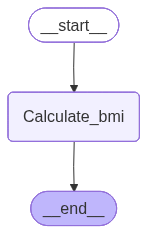

In [27]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [29]:
# END